<a href="https://colab.research.google.com/github/SRChandra/Capstoneproject_PID_TEAM2/blob/develop/PID_TEAM2_Diabetes_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Machine Learning–Based Clinical Decision Support for Early Diabetes Risk in Women (Pima Dataset)

**AIH Capstone Project 1 — Team 2**  
**Dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK).  
**Cohort constraint:** Female patients ≥21 years, Pima Indian heritage.  
**Records:** 768; **Features (8):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age; **Target:** Outcome (0/1).

> **Abstract**  
This notebook builds an end‑to‑end, reproducible ML pipeline to predict diabetes status (binary `Outcome`) from eight routinely collected predictors in the Pima Indians cohort. We address implausible zero entries via median imputation, handle class imbalance with **SMOTE**, perform **univariate analysis** (violin, box, KDE), apply **feature selection**, run **k‑fold cross‑validation** (mean & std), conduct **hyperparameter tuning**, provide **before/after comparison tables**, and deliver a **clean, reproducible pipeline** with clear comments. The notebook ends with **enhanced evaluation**, a refreshed **Model Card**, and a polished **export/inference** section. **This is a methodological demonstration and not a clinical diagnostic tool.**


In [4]:

# 1) Setup & Imports
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import io

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

# Optional XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# SMOTE & Imblearn Pipeline (fallback if not installed)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMB = True
except Exception:
    HAS_IMB = False

import joblib

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("xgboost:", 'yes' if HAS_XGB else 'no')
print("imblearn:", 'yes' if HAS_IMB else 'no')


Python: 3.12.12
numpy: 2.0.2
pandas: 2.2.2
seaborn: 0.13.2
xgboost: yes
imblearn: yes



## 2. Data Loading
Looks for a local `diabetes.csv`. If not found, attempts a download from public mirrors. Assigns standard column names if required.


In [5]:

LOCAL_PATHS = [Path('./diabetes.csv'), Path('./data/diabetes.csv')]
PUBLIC_URLS = [
    'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv',
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
]

COLUMNS = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

import urllib.request

def load_data():
    # local
    for p in LOCAL_PATHS:
        if p.exists():
            df = pd.read_csv(p)
            if df.shape[1] == 9:
                df.columns = COLUMNS
            return df, str(p)
    # try download (requires internet when executed)
    for url in PUBLIC_URLS:
        try:
            with urllib.request.urlopen(url, timeout=20) as r:
                data = r.read()
            df = pd.read_csv(io.BytesIO(data), header=0)
            if df.shape[1] == 9 and set(df.columns) != set(COLUMNS):
                df.columns = COLUMNS
            return df, url
        except Exception:
            continue
    raise FileNotFoundError('Place diabetes.csv next to the notebook and re-run.')

pima_data, data_source = load_data()
print('Loaded shape:', pima_data.shape)
print('Data source:', data_source)
pima_data.head()


Loaded shape: (768, 9)
Data source: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



## 3. Data Audit
Schema, stats, and implausible zeros (treated as missing in physiologic fields).


In [7]:

print('INFO:')
print(pima_data.info())

print('Describe:')
print(pima_data.describe(include='all'))

zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print('Zero counts (often indicate missing):')
print((pima_data[zero_cols] == 0).sum())


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Describe:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.7


## 4. EDA & Imputation
We visualize distributions and then replace physiologically implausible zeros with median values.


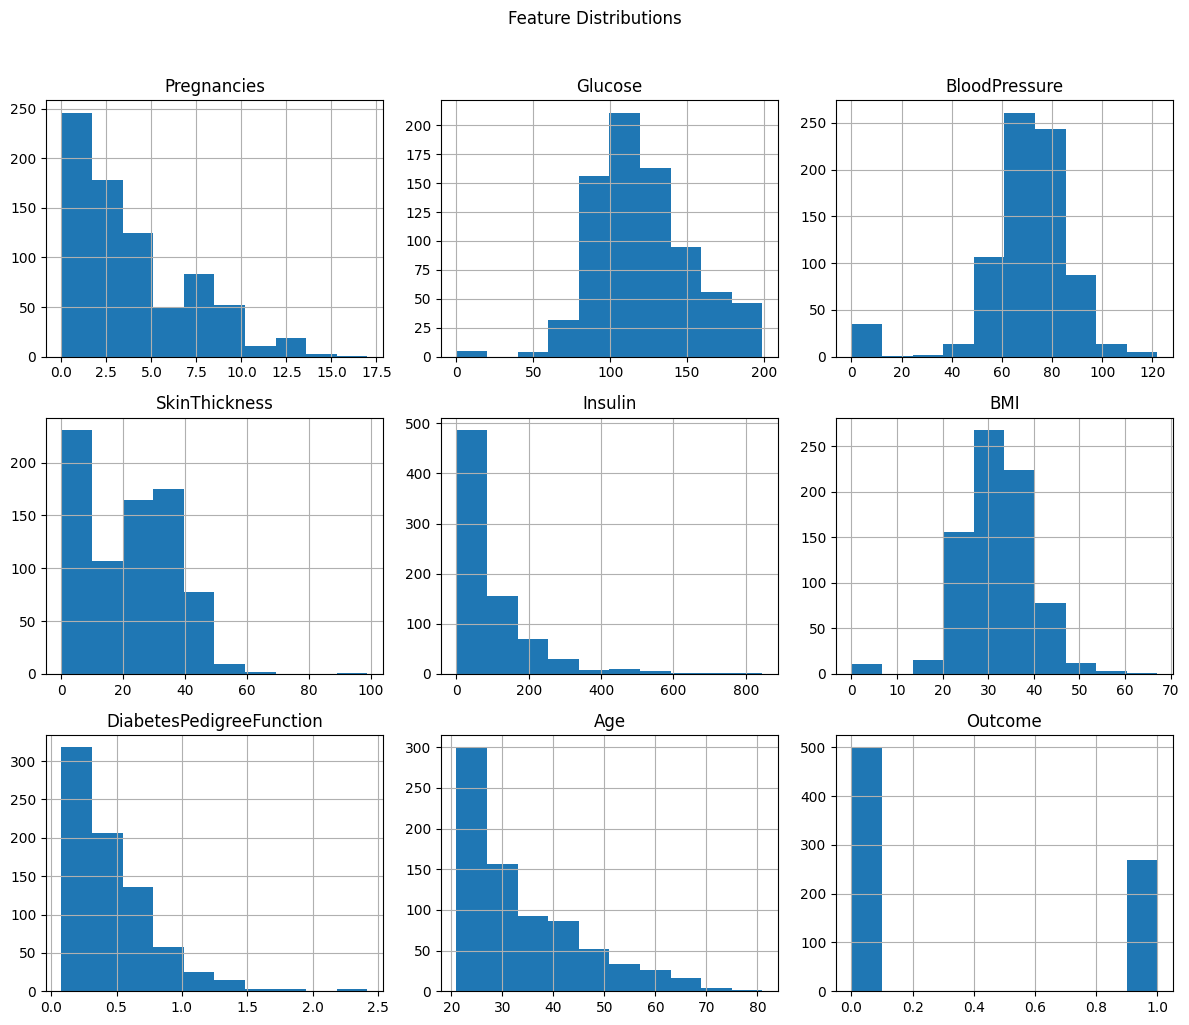

Remaining NaNs after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


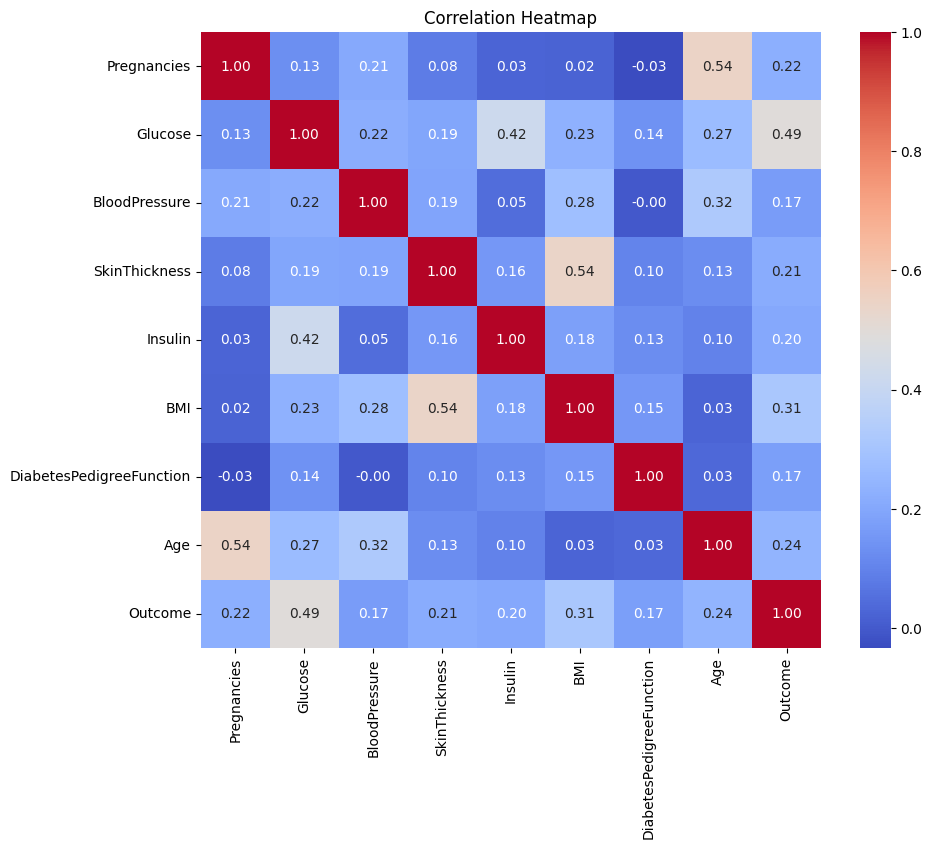

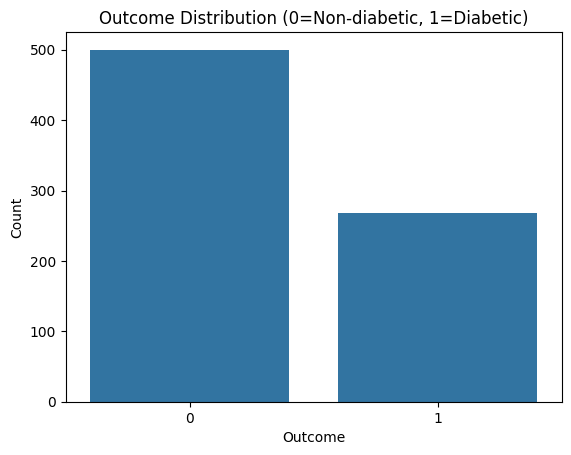

Outcome
0    500
1    268
Name: count, dtype: int64


In [8]:

# Histograms
_ = pima_data.hist(figsize=(12,10))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout(); plt.show()

# Prepare X/y
X = pima_data.drop(columns=['Outcome']).copy()
y = pima_data['Outcome'].astype(int)

# Treat zeros as missing for selected physiologic columns
cols_missing_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
X[cols_missing_zero] = X[cols_missing_zero].replace(0, np.nan)

# Median imputation
X_imputed = X.copy()
for c in cols_missing_zero:
    X_imputed[c].fillna(X_imputed[c].median(), inplace=True)

print('Remaining NaNs after imputation:')
print(X_imputed.isna().sum())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pd.concat([X_imputed, y], axis=1).corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Outcome distribution
sns.countplot(x=y)
plt.title('Outcome Distribution (0=Non-diabetic, 1=Diabetic)')
plt.xlabel('Outcome'); plt.ylabel('Count')
plt.show()
print(y.value_counts())



### 4.1 Univariate Analysis: Violin, Box, KDE
Check whether features separate the classes.


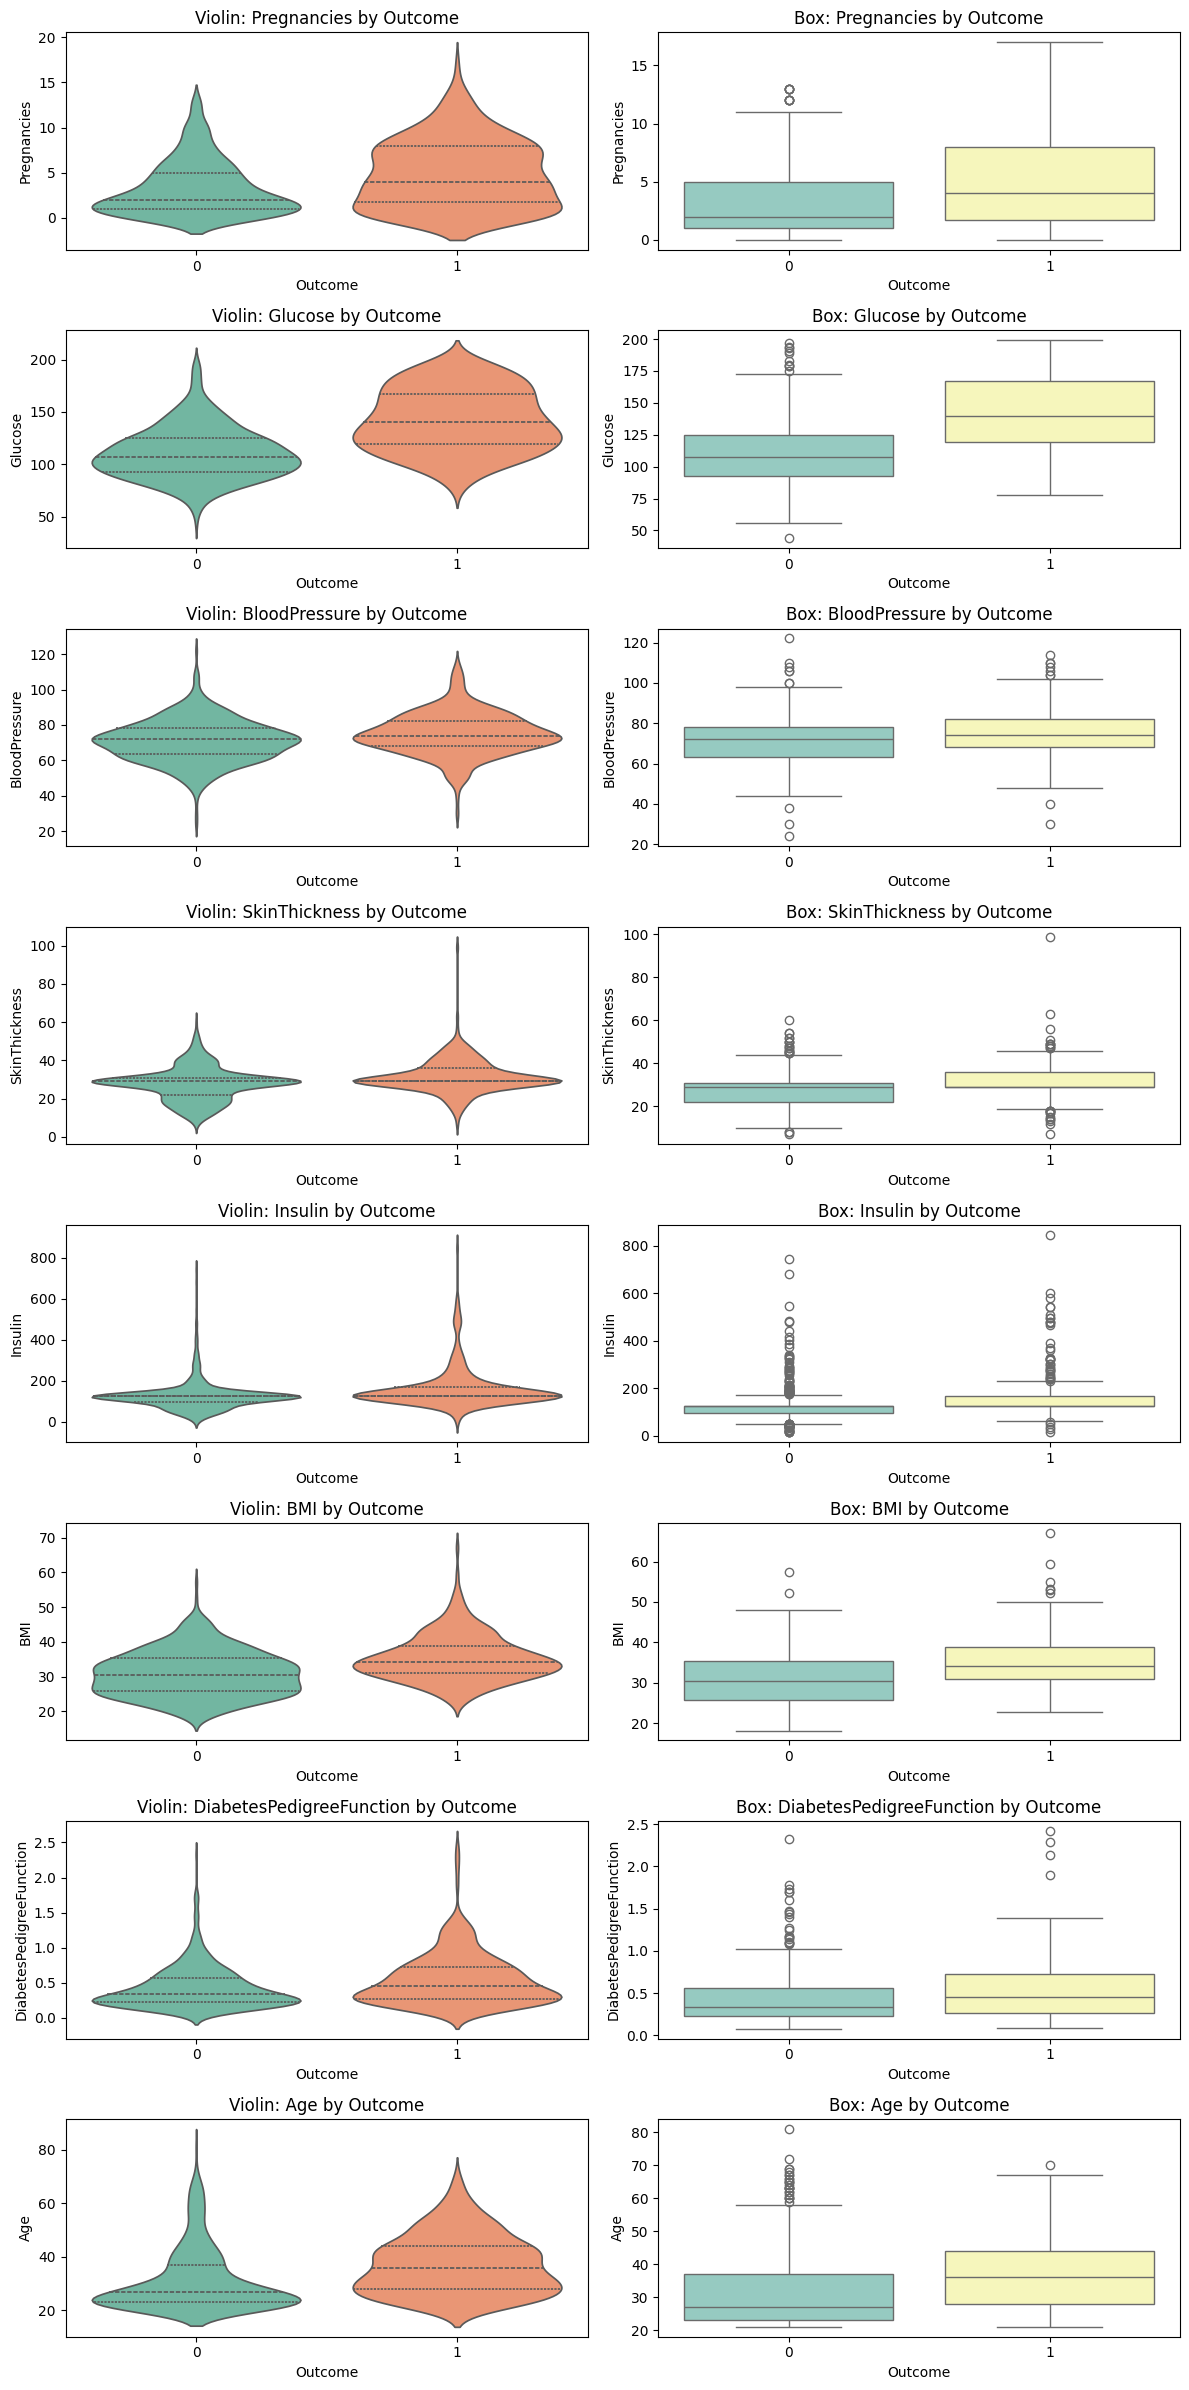

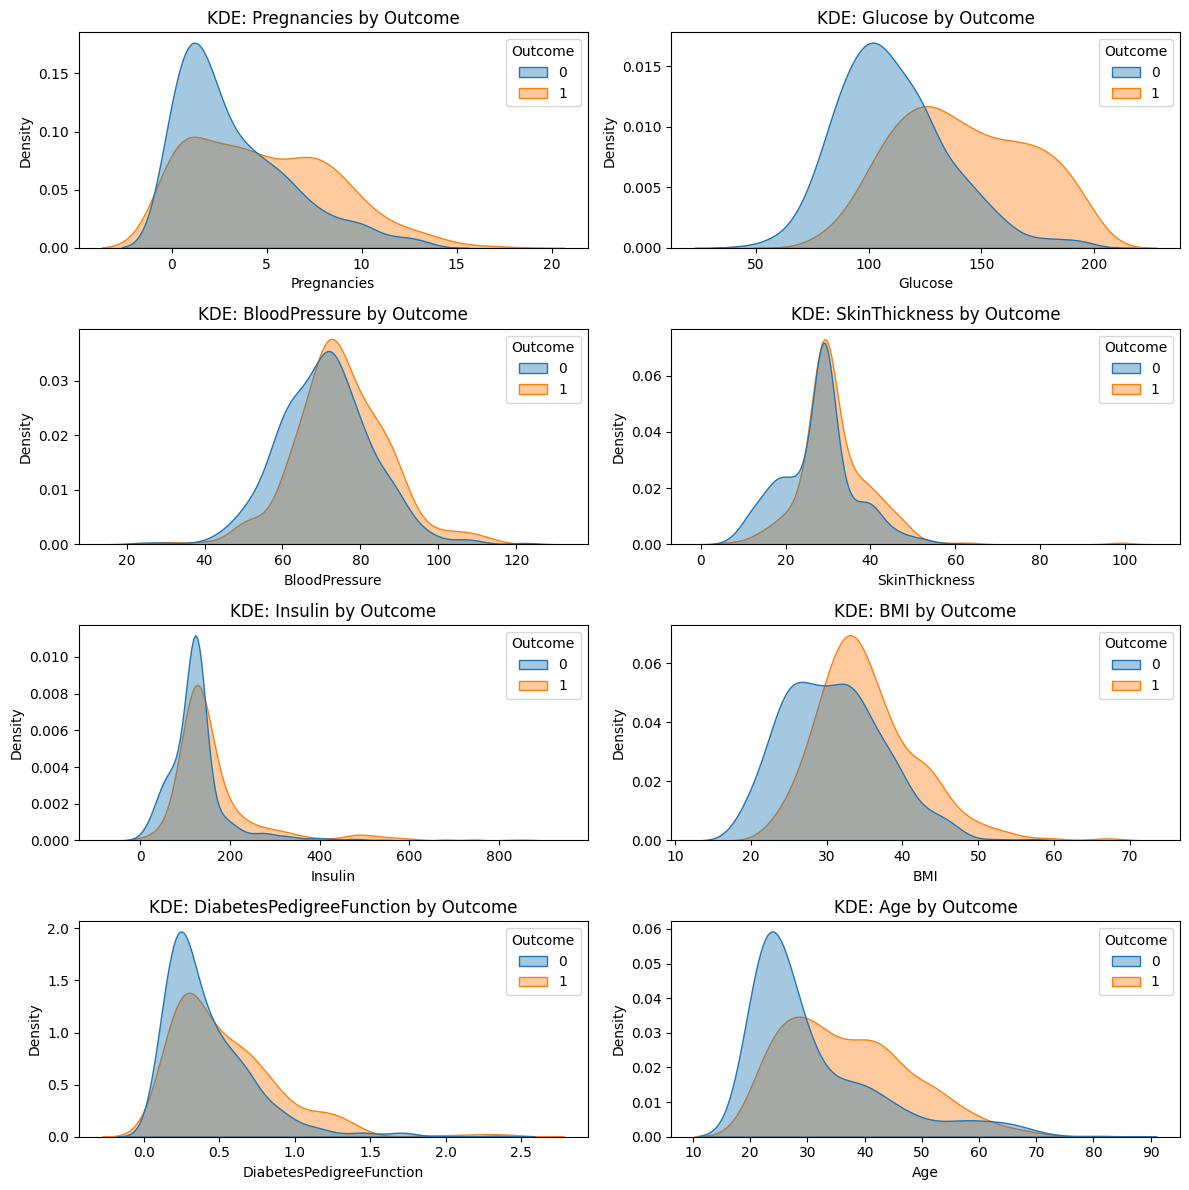

In [9]:

features = X_imputed.columns.tolist()

# Violin & Box plots per feature vs Outcome
ncols = 2
nrows = int(np.ceil(len(features)*2 / ncols) / 2) * 2  # ensure enough rows for both violin & box
plt.figure(figsize=(12, nrows*3))
for i, col in enumerate(features):
    plt.subplot(int(np.ceil(len(features))), 2, 2*i+1)
    sns.violinplot(x=y, y=X_imputed[col], palette='Set2', inner='quartile')
    plt.title(f'Violin: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)

    plt.subplot(int(np.ceil(len(features))), 2, 2*i+2)
    sns.boxplot(x=y, y=X_imputed[col], palette='Set3')
    plt.title(f'Box: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)
plt.tight_layout()
plt.show()

# KDE overlays (may be noisy; show a grid of plots)
cols = 2
rows = int(np.ceil(len(features)/cols))
plt.figure(figsize=(12, rows*3))
for i, col in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.kdeplot(data=pd.concat([X_imputed, y], axis=1), x=col, hue='Outcome', fill=True, common_norm=False, alpha=0.4)
        plt.title(f'KDE: {col} by Outcome')
    except Exception:
        plt.title(f'KDE: {col} (skipped)')
plt.tight_layout(); plt.show()



## 5. Modeling — Baselines and SMOTE Pipelines
We evaluate **without** and **with** SMOTE using consistent folds and report mean ± std across folds.


In [10]:

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

num_features = X_imputed.columns.tolist()
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features)
], remainder='drop')

# Base models
log_reg_est = LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
rf_est = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

# Pipelines: without SMOTE
pipe_nosmote_lr = Pipeline([('prep', preprocess), ('clf', log_reg_est)])
pipe_nosmote_rf = Pipeline([('prep', preprocess), ('clf', rf_est)])

# Pipelines: with SMOTE (if available)
if HAS_IMB:
    pipe_smote_lr = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', log_reg_est)])
    pipe_smote_rf = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', rf_est)])
else:
    print('WARNING: imbalanced-learn not available; falling back to class_weight="balanced"')
    log_reg_est = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
    rf_est = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
    pipe_smote_lr = Pipeline([('prep', preprocess), ('clf', log_reg_est)])
    pipe_smote_rf = Pipeline([('prep', preprocess), ('clf', rf_est)])

models_no = {
    'LogReg (No SMOTE)': pipe_nosmote_lr,
    'RandomForest (No SMOTE)': pipe_nosmote_rf,
}
models_sm = {
    'LogReg (SMOTE)': pipe_smote_lr,
    'RandomForest (SMOTE)': pipe_smote_rf,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Helper to compute metrics via CV
from sklearn.metrics import make_scorer

def cv_metrics(model, X, y, cv):
    scorers = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, zero_division=0),
        'recall': make_scorer(recall_score, zero_division=0),
        'f1': make_scorer(f1_score, zero_division=0),
        'roc_auc': 'roc_auc'
    }
    rows = []
    for name, scorer in scorers.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
        rows.append({'metric': name, 'mean': scores.mean(), 'std': scores.std(), 'scores': scores})
    return pd.DataFrame(rows).set_index('metric')

# Compute before/after tables
summary_rows = []
all_tables = {}
for label, mdl in list(models_no.items()) + list(models_sm.items()):
    table = cv_metrics(mdl, X_train, y_train, skf)
    all_tables[label] = table
    summary_rows.append({
        'model': label,
        'acc_mean': table.loc['accuracy','mean'], 'acc_std': table.loc['accuracy','std'],
        'f1_mean': table.loc['f1','mean'], 'f1_std': table.loc['f1','std'],
        'roc_auc_mean': table.loc['roc_auc','mean'], 'roc_auc_std': table.loc['roc_auc','std'],
    })

cv_summary = pd.DataFrame(summary_rows).sort_values('roc_auc_mean', ascending=False)
print('CV Summary (train folds):')
cv_summary


CV Summary (train folds):


,model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,LogReg (SMOTE),0.768719,0.009977,0.682785,0.012941,0.843182,0.019169
0,LogReg (No SMOTE),0.789857,0.019365,0.658275,0.023138,0.843068,0.019071
3,RandomForest (SMOTE),0.773584,0.019891,0.680381,0.026511,0.824312,0.023799
1,RandomForest (No SMOTE),0.770345,0.015942,0.643316,0.012238,0.821789,0.022054



### 5.1 Feature Selection Workflow (SelectKBest)
We select top 5 features via ANOVA to check if a lighter model improves stability.


In [11]:

select5 = SelectKBest(score_func=f_classif, k=5)

# Build feature-selection pipelines (with SMOTE if available)
if HAS_IMB:
    fs_lr = ImbPipeline([('prep', preprocess), ('sel', select5), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000))])
    fs_rf = ImbPipeline([('prep', preprocess), ('sel', select5), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
else:
    fs_lr = Pipeline([('prep', preprocess), ('sel', select5), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000))])
    fs_rf = Pipeline([('prep', preprocess), ('sel', select5), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))])

tables_fs = {}
for label, mdl in {
    'LogReg (SMOTE + FS)': fs_lr,
    'RandomForest (SMOTE + FS)': fs_rf,
}.items():
    table = cv_metrics(mdl, X_train, y_train, skf)
    tables_fs[label] = table

# Show selected feature names (fit once on whole training to display)
_ = select5.fit(preprocess.fit_transform(X_train), y_train)
selected_mask = select5.get_support()
selected_features = np.array(num_features)[selected_mask]
print('Selected top-5 features:', selected_features)

# Comparison table extended
for label, table in tables_fs.items():
    cv_summary.loc[len(cv_summary)] = {
        'model': label,
        'acc_mean': table.loc['accuracy','mean'], 'acc_std': table.loc['accuracy','std'],
        'f1_mean': table.loc['f1','mean'], 'f1_std': table.loc['f1','std'],
        'roc_auc_mean': table.loc['roc_auc','mean'], 'roc_auc_std': table.loc['roc_auc','std'],
    }

cv_summary.sort_values('roc_auc_mean', ascending=False)


Selected top-5 features: ['Glucose' 'SkinThickness' 'Insulin' 'BMI' 'Age']


,model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,LogReg (SMOTE),0.768719,0.009977,0.682785,0.012941,0.843182,0.019169
0,LogReg (No SMOTE),0.789857,0.019365,0.658275,0.023138,0.843068,0.019071
4,LogReg (SMOTE + FS),0.747514,0.016950,0.653036,0.017043,0.832108,0.023943
3,RandomForest (SMOTE),0.773584,0.019891,0.680381,0.026511,0.824312,0.023799
1,RandomForest (No SMOTE),0.770345,0.015942,0.643316,0.012238,0.821789,0.022054
5,RandomForest (SMOTE + FS),0.742650,0.036723,0.651241,0.042682,0.808192,0.024180



## 6. Hyperparameter Tuning (ROC‑AUC)
We tune both Logistic Regression (C) and Random Forest (depth, trees, split). Pipelines include SMOTE when available.


In [12]:

# Logistic Regression Tuning
if HAS_IMB:
    lr_pipe = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000))])
else:
    lr_pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000))])

lr_grid = {'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0]}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_lr = GridSearchCV(lr_pipe, lr_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_lr.fit(X_train, y_train)
print('Best LR params:', search_lr.best_params_)
print('Best LR CV ROC-AUC:', search_lr.best_score_)

# Random Forest Tuning
if HAS_IMB:
    rf_pipe = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(random_state=RANDOM_STATE))])
else:
    rf_pipe = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])

rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 6, 10],
    'clf__min_samples_split': [2, 5]
}
search_rf = GridSearchCV(rf_pipe, rf_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_rf.fit(X_train, y_train)
print('Best RF params:', search_rf.best_params_)
print('Best RF CV ROC-AUC:', search_rf.best_score_)

# Pick best tuned model by CV score
best_search = search_lr if search_lr.best_score_ >= search_rf.best_score_ else search_rf
best_model = best_search.best_estimator_
print('Selected tuned model:', 'LR' if best_search is search_lr else 'RF')


Best LR params: {'clf__C': 0.1}
Best LR CV ROC-AUC: 0.844264950166113
Best RF params: {'clf__max_depth': 6, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
Best RF CV ROC-AUC: 0.836280454042082
Selected tuned model: LR



## 7. Final Evaluation on Hold‑Out Test Set
We evaluate the **tuned** best model on the test split and plot CM, ROC, PR curves.


Classification report (TEST):               precision    recall  f1-score   support

           0      0.796     0.740     0.767       100
           1      0.574     0.648     0.609        54

    accuracy                          0.708       154
   macro avg      0.685     0.694     0.688       154
weighted avg      0.718     0.708     0.711       154



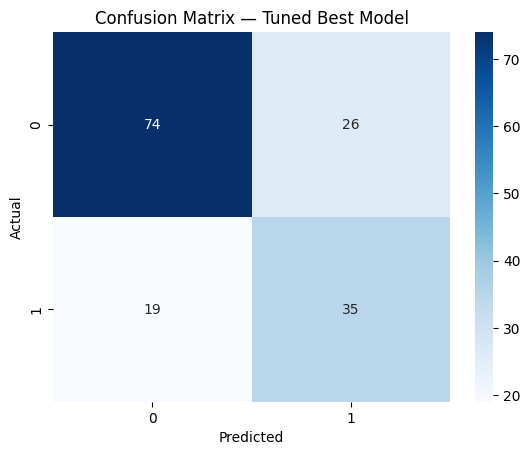

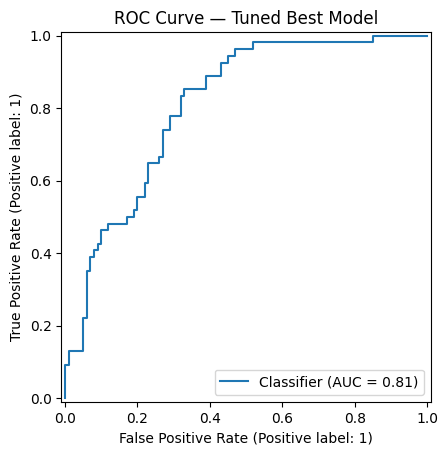

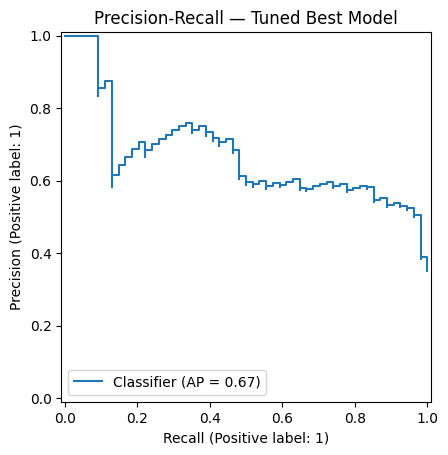

In [16]:

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print('Classification report (TEST):', classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Tuned Best Model')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — Tuned Best Model')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall — Tuned Best Model')
plt.show()



## 8. Export & Inference (Polished)
We export the tuned best model and show a single-record inference.


In [17]:

joblib.dump(best_model, 'best_model.joblib')
print('Saved model to best_model.joblib')

example = {
    'Pregnancies': 2,
    'Glucose': 140,
    'BloodPressure': 72,
    'SkinThickness': 32,
    'Insulin': 100,
    'BMI': 30.5,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 33
}

ex_df = pd.DataFrame([example])[X_imputed.columns]
pred_proba = best_model.predict_proba(ex_df)[:,1][0]
pred_label = int(pred_proba >= 0.5)
print({'prediction': pred_label, 'probability_1': round(float(pred_proba), 4)})


Saved model to best_model.joblib
{'prediction': 1, 'probability_1': 0.5491}



## 9. Model Card (Updated)
**Intended use:** Educational demonstration of an ML pipeline on the Pima dataset.  
**Not for:** Clinical diagnosis or patient care decisions.  
**Population:** Females ≥21 years, Pima Indian heritage.  
**Techniques:** Median imputation of zeros, SMOTE for imbalance, SelectKBest, Logistic Regression / Random Forest, k‑fold CV, ROC‑AUC‑driven tuning.  
**Evaluation:** Reported CV mean±std; final test metrics include accuracy, precision, recall, F1, ROC‑AUC, CM, ROC, PR curves.  
**Known limitations:** Small historical dataset; possible measurement zeros; probability calibration not performed; no subgroup/fairness analysis.  
**Reproducibility:** All hyperparameters and folds defined; random seeds set.
